# HOLIDAY PACKAGE PREDICTION

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [5]:
df = pd.read_csv("Travel.csv")

In [6]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [7]:
df['Gender'].value_counts()
df['MaritalStatus'].value_counts()
df['TypeofContact'].value_counts()
df['Gender']=df['Gender'].replace('Fe male','Female')
df['MaritalStatus']=df['MaritalStatus'].replace('Unmar ried','Unmarried')

In [8]:
##checking missing values
features_with_na = [features for features in df.columns if df[features].isnull().sum() >=1]
for feature in features_with_na:
    print(feature, np.round(df[feature].isnull().mean()*100,5), '%missing values')

Age 4.62357 %missing values
TypeofContact 0.51146 %missing values
DurationOfPitch 5.13502 %missing values
NumberOfFollowups 0.92062 %missing values
PreferredPropertyStar 0.53191 %missing values
NumberOfTrips 2.86416 %missing values
NumberOfChildrenVisiting 1.35025 %missing values
MonthlyIncome 4.76678 %missing values


In [9]:
## statistics of numerical features
df[features_with_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


In [10]:
# Numerical columns → median
num_cols = ['Age', 'NumberOfFollowups', 'NumberOfTrips', 'MonthlyIncome', 'DurationOfPitch']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns → mode
cat_cols = ['TypeofContact', 'PreferredPropertyStar', 'NumberOfChildrenVisiting']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [12]:
df.drop('CustomerID',inplace=True, axis=1)

In [13]:
# create new column for feature 
df['TotalVisiting']=df['NumberOfPersonVisiting']+df['NumberOfChildrenVisiting']
df.drop(columns=['NumberOfPersonVisiting','NumberOfChildrenVisiting'], inplace=True)

In [14]:
## get all the numerical features
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print('Num of numerical features: ', len(num_features))

Num of numerical features:  18


In [15]:
##Categorical features
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('Num of categorical features: ', len(cat_features))

Num of categorical features:  0


In [16]:
## discrete features
discrete_features = [feature for feature in num_features if len(df[feature].unique())<25]
print('No. of Discrete features: ', len(discrete_features))

No. of Discrete features:  15


In [17]:
## continuous features
continuous_features = [feature for feature in num_features if feature not in discrete_features]
print('No. of Continuous features: ', len(continuous_features))

No. of Continuous features:  3


In [18]:
# convert numeric columns properly
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# fix string dtype
for col in df.columns:
    if df[col].dtype.name == 'string':
        df[col] = df[col].astype('object')

In [19]:
X = df.drop(['ProdTaken'], axis=1)
y = df['ProdTaken']

In [20]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
num_features = x_train.select_dtypes(include=['int64','float64']).columns
cat_features = x_train.select_dtypes(include=['object']).columns

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

In [23]:
x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)

APPLY ML TRAINING (ADABOOST)

In [24]:
import sys
!{sys.executable} -m pip install imbalanced-learn

In [25]:
import imblearn
print("imblearn installed successfully!")

imblearn installed successfully!


In [28]:
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [29]:
# =========================================
# IMPORTS
# =========================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier   # <-- Added

# =========================================
# FIX MISSING VALUES
# =========================================
imputer = SimpleImputer(strategy="mean")
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

# =========================================
# FIX CLASS IMBALANCE (SMOTE)
# =========================================
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

# =========================================
# MODELS
# =========================================
models = {
    "DecisionTree": DecisionTreeClassifier(class_weight="balanced"),
    "RandomForest": RandomForestClassifier(class_weight="balanced"),
    "AdaBoost": AdaBoostClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(
        eval_metric="logloss", 
        random_state=42
    )   # <-- Added
}

# =========================================
# TRAIN + EVALUATE
# =========================================
for name, model in models.items():

    print(f"\n{name}")

    # Train model
    model.fit(x_train, y_train)

    # Predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # -------- Training performance --------
    print("Model performance for Training set")
    print(f"- Accuracy : {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"- F1 score : {f1_score(y_train, y_train_pred):.4f}")
    print(f"- Precision: {precision_score(y_train, y_train_pred):.4f}")
    print(f"- Recall   : {recall_score(y_train, y_train_pred):.4f}")
    print(f"- Roc Auc Score: {roc_auc_score(y_train, y_train_pred):.4f}")

    print("-" * 40)

    # -------- Testing performance --------
    print("Model performance for Test set")
    print(f"- Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
    print(f"- F1 score : {f1_score(y_test, y_test_pred):.4f}")
    print(f"- Precision: {precision_score(y_test, y_test_pred):.4f}")
    print(f"- Recall   : {recall_score(y_test, y_test_pred):.4f}")
    print(f"- Roc Auc Score: {roc_auc_score(y_test, y_test_pred):.4f}")

    print("=" * 40)


DecisionTree
Model performance for Training set
- Accuracy : 1.0000
- F1 score : 1.0000
- Precision: 1.0000
- Recall   : 1.0000
- Roc Auc Score: 1.0000
----------------------------------------
Model performance for Test set
- Accuracy : 0.8742
- F1 score : 0.6805
- Precision: 0.6753
- Recall   : 0.6859
- Roc Auc Score: 0.8029

RandomForest
Model performance for Training set
- Accuracy : 1.0000
- F1 score : 1.0000
- Precision: 1.0000
- Recall   : 1.0000
- Roc Auc Score: 1.0000
----------------------------------------
Model performance for Test set
- Accuracy : 0.8988
- F1 score : 0.6991
- Precision: 0.8333
- Recall   : 0.6021
- Roc Auc Score: 0.7864

AdaBoost
Model performance for Training set
- Accuracy : 0.8064
- F1 score : 0.7991
- Precision: 0.8302
- Recall   : 0.7702
- Roc Auc Score: 0.8064
----------------------------------------
Model performance for Test set
- Accuracy : 0.7495
- F1 score : 0.4208
- Precision: 0.3836
- Recall   : 0.4660
- Roc Auc Score: 0.6421

GradientBoosting

In [30]:
# Random Forest parameters
rf_params = {
    "max_depth": [5, 8, 15, None, 10],
    "max_features": [5, 7, "sqrt", 8],   # 'auto' removed in new sklearn versions
    "min_samples_split": [2, 8, 15, 20],
    "n_estimators": [100, 200, 500, 1000]
}

# AdaBoost parameters
adaboost_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1]
}

# Gradient Boosting parameters
gradient_params = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.7, 0.8, 1.0],
    "min_samples_split": [2, 5, 10]
}
# XGBoost parameters
xgboost_params = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2],
    "reg_lambda": [1, 1.5, 2]  # L2 regularization
}

In [31]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier   # <-- import XGBoost

randomcv_models = [
    ("RF", RandomForestClassifier(), rf_params),
    ("AB", AdaBoostClassifier(), adaboost_params),
    ("GB", GradientBoostingClassifier(), gradient_params),
    ("XGB", XGBClassifier(eval_metric="logloss", random_state=42), xgboost_params)  # <-- added
]

In [32]:
from sklearn.model_selection import RandomizedSearchCV

model_params = {}

for name, model, params in randomcv_models:
    print(f"\n🔍 Tuning {name}...")

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=50,          # try 50 random combinations
        cv=3,
        scoring="f1",       # change to "roc_auc" if needed
        verbose=2,
        n_jobs=-1,
        random_state=42
    )

    random_search.fit(x_train, y_train)

    # Save best parameters
    model_params[name] = random_search.best_params_

    print(f"✔ Best F1 score for {name}: {random_search.best_score_:.4f}")
    print(f"✔ Best Params: {random_search.best_params_}")

# Final summary
print("\n========== BEST PARAMETERS ==========")
for model_name, best_params in model_params.items():
    print(f"\nModel: {model_name}")
    print(best_params)


🔍 Tuning RF...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
✔ Best F1 score for RF: 0.9288
✔ Best Params: {'n_estimators': 500, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': None}

🔍 Tuning AB...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
✔ Best F1 score for AB: 0.7768
✔ Best Params: {'n_estimators': 200, 'learning_rate': 1}

🔍 Tuning GB...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
✔ Best F1 score for GB: 0.8528
✔ Best Params: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.1}

🔍 Tuning XGB...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
✔ Best F1 score for XGB: 0.8765
✔ Best Params: {'subsample': 0.8, 'reg_lambda': 1, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0}

========== BEST PARAMETERS ==========

Model: RF
{'n_estimators': 500, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': None

In [33]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

# Best models with tuned parameters
best_rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=2,
    max_features='sqrt',
    max_depth=None,
    random_state=42
)

best_ab = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=1,
    random_state=42
)

best_gb = GradientBoostingClassifier(
    subsample=1.0,
    n_estimators=300,
    min_samples_split=2,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
from xgboost import XGBClassifier

# Best XGBoost model with tuned parameters
best_xgb = XGBClassifier(
    subsample=0.8,
    reg_lambda=1,
    n_estimators=200,
    max_depth=8,
    learning_rate=0.2,
    gamma=0.1,
    colsample_bytree=1.0,
    eval_metric="logloss",
    random_state=42
)

# Train XGBoost
best_xgb.fit(x_train, y_train)

# Train models
best_rf.fit(x_train, y_train)
best_ab.fit(x_train, y_train)
best_gb.fit(x_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, name):
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    print(f"\n{name}")
    print("Training:")
    print("Accuracy:", accuracy_score(y_train, y_train_pred))
    print("F1:", f1_score(y_train, y_train_pred))
    print("Recall:", recall_score(y_train, y_train_pred))
    print("Precision:", precision_score(y_train, y_train_pred))
    print("ROC AUC:", roc_auc_score(y_train, y_train_pred))

    print("Testing:")
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("F1:", f1_score(y_test, y_test_pred))
    print("Recall:", recall_score(y_test, y_test_pred))
    print("Precision:", precision_score(y_test, y_test_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_test_pred))
    print("-" * 40)

# Compare all models
evaluate_model(best_rf, "Random Forest (Tuned)")
evaluate_model(best_ab, "AdaBoost (Tuned)")
evaluate_model(best_gb, "Gradient Boosting (Tuned)")
evaluate_model(best_xgb, "XGBoost (Tuned)")   # <-- Added


Random Forest (Tuned)
Training:
Accuracy: 1.0
F1: 1.0
Recall: 1.0
Precision: 1.0
ROC AUC: 1.0
Testing:
Accuracy: 0.901840490797546
F1: 0.7142857142857143
Recall: 0.6282722513089005
Precision: 0.8275862068965517
ROC AUC: 0.7982530252732559
----------------------------------------

AdaBoost (Tuned)
Training:
Accuracy: 0.8458032065388242
F1: 0.840617384240455
Recall: 0.8132662684690349
Precision: 0.8698722259583053
ROC AUC: 0.8458032065388243
Testing:
Accuracy: 0.7658486707566462
F1: 0.42317380352644834
Recall: 0.4397905759162304
Precision: 0.4077669902912621
ROC AUC: 0.6423857580978865
----------------------------------------

Gradient Boosting (Tuned)
Training:
Accuracy: 0.9891543539767369
F1: 0.9890493572448817
Recall: 0.9795661741590694
Precision: 0.9987179487179487
ROC AUC: 0.9891543539767369
Testing:
Accuracy: 0.8865030674846626
F1: 0.6584615384615384
Recall: 0.5602094240837696
Precision: 0.7985074626865671
ROC AUC: 0.7629509636301948
----------------------------------------

XGBoo

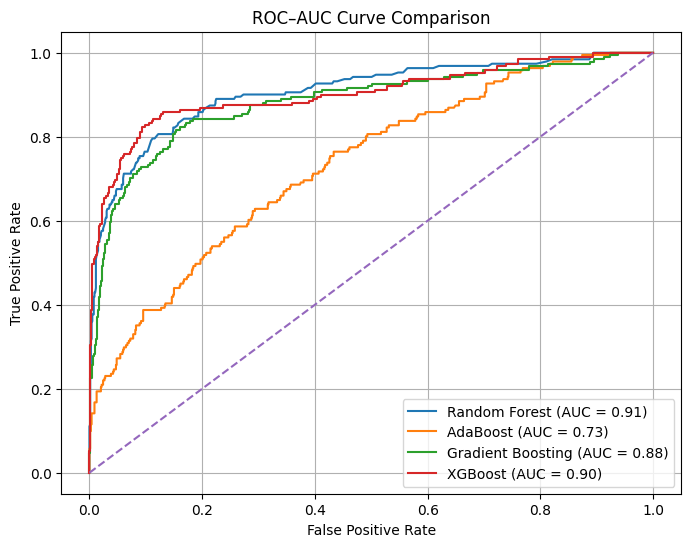

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities
rf_probs = best_rf.predict_proba(x_test)[:, 1]
ab_probs = best_ab.predict_proba(x_test)[:, 1]
gb_probs = best_gb.predict_proba(x_test)[:, 1]
xgb_probs = best_xgb.predict_proba(x_test)[:, 1]   # <-- Added

# Calculate ROC curve values
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
ab_fpr, ab_tpr, _ = roc_curve(y_test, ab_probs)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)   # <-- Added

# Calculate AUC
rf_auc = roc_auc_score(y_test, rf_probs)
ab_auc = roc_auc_score(y_test, ab_probs)
gb_auc = roc_auc_score(y_test, gb_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)   # <-- Added

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.2f})")
plt.plot(ab_fpr, ab_tpr, label=f"AdaBoost (AUC = {ab_auc:.2f})")
plt.plot(gb_fpr, gb_tpr, label=f"Gradient Boosting (AUC = {gb_auc:.2f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.2f})")  # <-- Added

# Baseline (random model)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

AdaBoost regression model

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4
)

gbr.fit(x_train, y_train)
print("R2:", gbr.score(x_test, y_test))

R2: 0.23214277380625647


In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

ab_reg = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=50,
    learning_rate=1,
    random_state=42
)

ab_reg.fit(x_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeR...r(max_depth=4)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.

In [ ]:
# Predictions
y_train_pred = ab_reg.predict(x_train)
y_test_pred = ab_reg.predict(x_test)

print("Training Performance")
print("R2 Score:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("MSE:", mean_squared_error(y_train, y_train_pred))

print("\nTesting Performance")
print("R2 Score:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))

Training Performance
R2 Score: 0.2903648525057091
MAE: 0.40251296136059894
MSE: 0.17740878687357273

Testing Performance
R2 Score: -0.22006283682394656
MAE: 0.4247935115303701
MSE: 0.191739940702474


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1],
    "estimator__max_depth": [2, 3, 4]
}

search = RandomizedSearchCV(
    AdaBoostRegressor(estimator=DecisionTreeRegressor()),
    params,
    cv=3,
    n_iter=10,
    n_jobs=-1
)

search.fit(x_train, y_train)
print(search.best_params_)

{'n_estimators': 50, 'learning_rate': 0.01, 'estimator__max_depth': 4}


In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Final model using best parameters
final_model = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=50,
    learning_rate=1,
    random_state=42
)

final_model.fit(x_train, y_train)


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeR...r(max_depth=4)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.

In [ ]:
# Predictions
y_train_pred = final_model.predict(x_train)
y_test_pred = final_model.predict(x_test)

print("Training Performance")
print("R2 Score:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("MSE:", mean_squared_error(y_train, y_train_pred))

print("\nTesting Performance")
print("R2 Score:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))

Training Performance
R2 Score: 0.2903648525057091
MAE: 0.40251296136059894
MSE: 0.17740878687357273

Testing Performance
R2 Score: -0.22006283682394656
MAE: 0.4247935115303701
MSE: 0.191739940702474
